## Recoleccion, preparacion, preprocesamiento

In [87]:
#Instalación de librerías
%pip install alpaca-py scikit-learn pandas numpy matplotlib seaborn joblib pytz python-dotenv

In [88]:
# Imports generales
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Fechas
from datetime import datetime

# Alpaca — obtención de datos
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

# Scikit-learn — preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Scikit-learn — modelos
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# Scikit-learn — métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Guardar modelos
import joblib

# Configuración visual
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("!!Librerías cargadas correctamente")

!!Librerías cargadas correctamente


In [89]:
from google.colab import userdata


In [90]:
# Credenciales de Alpaca (Paper Trading)

from dotenv import load_dotenv
import os

# Cargar variables del .env
load_dotenv()

API_KEY = userdata.get('API_KEY')
SECRET_TOKEN = userdata.get('SECRET_TOKEN')

# Validación
if not API_KEY or not SECRET_TOKEN:
    # Provide instructions for the user to create/update the .env file
    print("Error: Faltan credenciales en el archivo .env")
    print("Por favor, crea un archivo llamado '.env' en la misma carpeta que este notebook ")
    print("y añade tus credenciales de Alpaca en el siguiente formato:")
    print("API_KEY='YOUR_API_KEY'")
    print("SECRET_TOKEN='YOUR_SECRET_TOKEN'")
    raise ValueError("Faltan credenciales en el archivo .env")

client = StockHistoricalDataClient(API_KEY, SECRET_TOKEN)

print("Cliente de Alpaca conectado")


Cliente de Alpaca conectado


In [91]:
#  Descarga de datos históricos de INTC

request_params = StockBarsRequest(
    symbol_or_symbols="INTC",
    timeframe=TimeFrame.Day,          # Barras diarias
    start=datetime(2019, 1, 1),       # Desde enero 2019
    end=datetime(2024, 12, 31),       # Hasta diciembre 2024
    feed="iex"                        # Feed gratuito
)

# Solicitud a la API
bars = client.get_stock_bars(request_params)

# Convertir a DataFrame
df_raw = bars.df.reset_index()

# Vista previa
print(f"Datos descargados: {df_raw.shape[0]} registros, {df_raw.shape[1]} columnas")
print(f"\nColumnas disponibles:\n{df_raw.columns.tolist()}")
print(f"\nPrimeras filas:")
df_raw.head()

Datos descargados: 1115 registros, 9 columnas

Columnas disponibles:
['symbol', 'timestamp', 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap']

Primeras filas:


,symbol,timestamp,open,high,low,close,volume,trade_count,vwap
0,INTC,2020-07-27 04:00:00+00:00,51.03,51.135,49.51,49.545,2381133.0,13266.0,50.125079
1,INTC,2020-07-28 04:00:00+00:00,49.51,50.190,49.14,49.240,1072342.0,6455.0,49.622185
2,INTC,2020-07-29 04:00:00+00:00,49.43,49.470,47.90,48.085,1115663.0,7770.0,48.271563
3,INTC,2020-07-30 04:00:00+00:00,47.81,48.485,47.59,47.990,538909.0,4731.0,47.943802
4,INTC,2020-07-31 04:00:00+00:00,48.12,48.305,47.00,47.720,524091.0,4089.0,47.639135


In [92]:
# Limpieza inicial del DataFrame

# La columna 'symbol' no aporta información (siempre es "INTC")
df_raw = df_raw.drop(columns=["symbol"])

# Aseguramos que timestamp sea de tipo datetime y lo usamos como índice
df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"])
df_raw = df_raw.set_index("timestamp")

# Verificamos que no haya nulos
print(f"Valores nulos por columna:")
print(df_raw.isnull().sum())
print(f"\nShape del dataset: {df_raw.shape}")
df_raw.head()

Valores nulos por columna:
open           0
high           0
low            0
close          0
volume         0
trade_count    0
vwap           0
dtype: int64

Shape del dataset: (1115, 7)


,open,high,low,close,volume,trade_count,vwap
timestamp,,,,,,,
2020-07-27 04:00:00+00:00,51.03,51.135,49.51,49.545,2381133.0,13266.0,50.125079
2020-07-28 04:00:00+00:00,49.51,50.190,49.14,49.240,1072342.0,6455.0,49.622185
2020-07-29 04:00:00+00:00,49.43,49.470,47.90,48.085,1115663.0,7770.0,48.271563
2020-07-30 04:00:00+00:00,47.81,48.485,47.59,47.990,538909.0,4731.0,47.943802
2020-07-31 04:00:00+00:00,48.12,48.305,47.00,47.720,524091.0,4089.0,47.639135


In [93]:
# Ingeniería de características

df = df_raw.copy()

# 1 Retorno diario
# Variación porcentual del precio de cierre respecto al día anterior
df["daily_return"] = df["close"].pct_change()

# 2 Medias móviles
# Promedio del precio de cierre en los últimos N días
df["ma_7"]  = df["close"].rolling(window=7).mean()
df["ma_21"] = df["close"].rolling(window=21).mean()

# 3 Volatilidad
# Qué tanto varía el precio en los últimos 7 días
df["volatility_7"] = df["daily_return"].rolling(window=7).std()

# 4 Rango diario
# Diferencia entre el precio más alto y más bajo del día
df["daily_range"] = df["high"] - df["low"]

# 5 Variable objetivo (target)
# El precio de cierre del día SIGUIENTE es lo que queremos predecir
df["target"] = df["close"].shift(-1)

# Eliminar filas con NaN
df = df.dropna()

print(f"Características creadas correctamente")
print(f"Shape del dataset: {df.shape}")
print(f"\nColumnas del dataset:")
print(df.columns.tolist())
df.head()

Características creadas correctamente
Shape del dataset: (1094, 13)

Columnas del dataset:
['open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'daily_return', 'ma_7', 'ma_21', 'volatility_7', 'daily_range', 'target']


,open,high,low,close,volume,trade_count,vwap,daily_return,ma_7,ma_21,volatility_7,daily_range,target
timestamp,,,,,,,,,,,,,
2020-08-24 04:00:00+00:00,49.350,49.385,48.820,49.135,308299.0,3046.0,49.061107,-0.003044,48.912143,48.714048,0.007865,0.565,49.445
2020-08-25 04:00:00+00:00,49.305,49.860,49.220,49.445,459442.0,3638.0,49.439455,0.006309,48.989286,48.709286,0.007779,0.640,49.515
2020-08-26 04:00:00+00:00,49.355,49.665,49.240,49.515,237884.0,2183.0,49.484368,0.001416,49.075000,48.722381,0.007756,0.425,49.430
2020-08-27 04:00:00+00:00,49.780,49.920,49.195,49.430,281181.0,2319.0,49.583347,-0.001717,49.188571,48.786429,0.007242,0.725,50.405
2020-08-28 04:00:00+00:00,49.505,50.800,49.495,50.405,460013.0,3417.0,50.323914,0.019725,49.480000,48.901429,0.008787,1.305,51.035


In [94]:
# Normalización de los datos

# Separamos las características (X) del target (y)
# El target no se normaliza — queremos predicciones del precio real
X = df.drop(columns=["target"])
y = df["target"]

# Aplicamos StandardScaler a las características
# StandardScaler transforma cada columna para que tenga:
#   - Media = 0
#   - Desviación estándar = 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertimos de vuelta a DataFrame para mantener los nombres de columnas
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("Normalización completada")
print(f"\nEstadísticas post-normalización:")
print(X_scaled.describe().round(2))

Normalización completada

Estadísticas post-normalización:
          open     high      low    close   volume  trade_count     vwap  \
count  1094.00  1094.00  1094.00  1094.00  1094.00      1094.00  1094.00   
mean      0.00     0.00     0.00    -0.00     0.00        -0.00     0.00   
std       1.00     1.00     1.00     1.00     1.00         1.00     1.00   
min      -1.82    -1.84    -1.83    -1.83    -1.19        -1.89    -1.84   
25%      -0.86    -0.86    -0.85    -0.86    -0.64        -0.69    -0.86   
50%       0.01    -0.01    -0.02    -0.01    -0.25        -0.17    -0.01   
75%       0.83     0.82     0.83     0.83     0.28         0.44     0.83   
max       2.31     2.28     2.24     2.32     7.55         7.48     2.28   

       daily_return     ma_7    ma_21  volatility_7  daily_range  
count       1094.00  1094.00  1094.00       1094.00      1094.00  
mean          -0.00    -0.00     0.00         -0.00        -0.00  
std            1.00     1.00     1.00          1.00    

In [95]:
# Guardar datos procesados

import os

# Guardamos el dataset procesado en CSV para que el equipo lo use
df.to_csv("/home/data/intc_processed.csv")
X_scaled.to_csv("/home/data/intc_X_scaled.csv")
y.to_csv("/home/data/intc_y.csv")

# Guardamos el scaler entrenado para usarlo en predicciones futuras
joblib.dump(scaler, "/home/models/scaler.pkl")

print("Dataset procesado guardado en /data/intc_processed.csv")
print("X escalado guardado en /data/intc_X_scaled.csv")
print("y guardado en /data/intc_y.csv")
print("Scaler guardado en /models/scaler.pkl")

Dataset procesado guardado en /data/intc_processed.csv
X escalado guardado en /data/intc_X_scaled.csv
y guardado en /data/intc_y.csv
Scaler guardado en /models/scaler.pkl


## EDA

In [96]:
# EDA | Gráficas analíticas del dataset
# Importamos las librerias que necesitamos para el analisis visual
# pandas y numpy ya estan cargados desde la parte anterior

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os

# Ajustamos el estilo visual igual al que uso Jonathan
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)

# Carpeta donde se van a guardar las graficas
os.makedirs("../plots", exist_ok=True)

# Verificamos que el df sigue disponible con todas sus columnas
print(f"Registros disponibles: {df.shape[0]}")
print(f"Columnas: {df.columns.tolist()}")
df.head()

Registros disponibles: 1094
Columnas: ['open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'daily_return', 'ma_7', 'ma_21', 'volatility_7', 'daily_range', 'target']


,open,high,low,close,volume,trade_count,vwap,daily_return,ma_7,ma_21,volatility_7,daily_range,target
timestamp,,,,,,,,,,,,,
2020-08-24 04:00:00+00:00,49.350,49.385,48.820,49.135,308299.0,3046.0,49.061107,-0.003044,48.912143,48.714048,0.007865,0.565,49.445
2020-08-25 04:00:00+00:00,49.305,49.860,49.220,49.445,459442.0,3638.0,49.439455,0.006309,48.989286,48.709286,0.007779,0.640,49.515
2020-08-26 04:00:00+00:00,49.355,49.665,49.240,49.515,237884.0,2183.0,49.484368,0.001416,49.075000,48.722381,0.007756,0.425,49.430
2020-08-27 04:00:00+00:00,49.780,49.920,49.195,49.430,281181.0,2319.0,49.583347,-0.001717,49.188571,48.786429,0.007242,0.725,50.405
2020-08-28 04:00:00+00:00,49.505,50.800,49.495,50.405,460013.0,3417.0,50.323914,0.019725,49.480000,48.901429,0.008787,1.305,51.035


In [97]:
# Estadísticas descriptivas e interpretación
# Estadisticas generales del dataset de INTC
# Esto nos da una primera vision del comportamiento del activo

print(df.describe().round(3))

           open      high       low     close       volume  trade_count  \
count  1094.000  1094.000  1094.000  1094.000     1094.000     1094.000   
mean     40.668    41.195    40.129    40.660  1074859.223     8115.887   
std      11.906    11.998    11.811    11.907   708563.157     3601.751   
min      18.960    19.100    18.520    18.900   231307.000     1327.000   
25%      30.375    30.841    30.051    30.428   624019.250     5623.750   
50%      40.750    41.088    39.920    40.585   894693.000     7501.500   
75%      50.519    51.024    49.950    50.529  1273060.250     9702.000   
max      68.200    68.480    66.630    68.265  6421167.000    35051.000   

           vwap  daily_return      ma_7     ma_21  volatility_7  daily_range  \
count  1094.000      1094.000  1094.000  1094.000      1094.000     1094.000   
mean     40.657        -0.000    40.738    40.920         0.022        1.066   
std      11.907         0.025    11.819    11.628         0.012        0.542   
min 

In [98]:
# Sacamos los valores mas importantes para interpretarlos

print(f"Precio promedio de cierre   : ${df['close'].mean():.2f} USD")
print(f"Precio minimo registrado    : ${df['close'].min():.2f} USD")
print(f"Precio maximo registrado    : ${df['close'].max():.2f} USD")
print(f"Retorno diario promedio     : {df['daily_return'].mean()*100:.4f}%")
print(f"Volatilidad promedio (7d)   : {df['volatility_7'].mean()*100:.4f}%")
print(f"Volumen promedio diario     : {df['volume'].mean():,.0f} acciones")
print(f"Rango diario promedio       : ${df['daily_range'].mean():.4f} USD")
print(f"Dias con retorno positivo   : {(df['daily_return'] > 0).mean()*100:.1f}%")
print(f"Dias con retorno negativo   : {(df['daily_return'] < 0).mean()*100:.1f}%")

Precio promedio de cierre   : $40.66 USD
Precio minimo registrado    : $18.90 USD
Precio maximo registrado    : $68.27 USD
Retorno diario promedio     : -0.0484%
Volatilidad promedio (7d)   : 2.2096%
Volumen promedio diario     : 1,074,859 acciones
Rango diario promedio       : $1.0661 USD
Dias con retorno positivo   : 49.5%
Dias con retorno negativo   : 49.7%


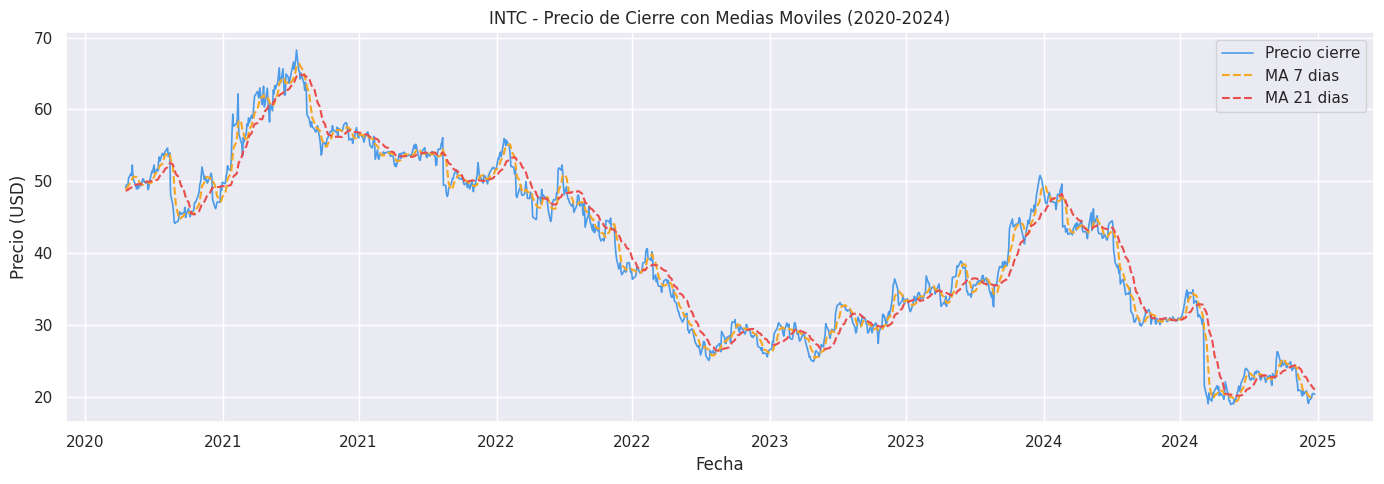

In [99]:
#Gráfica 1 — Precio de cierre con medias móviles
# Graficamos el precio historico de INTC junto a las medias moviles
# ma_7 y ma_21 fueron calculadas en el preprocesamiento por Jonathan
# Nos ayudan a ver la tendencia general del precio en el tiempo

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df["close"], color="#4C9BE8", linewidth=1.2, label="Precio cierre")
ax.plot(df.index, df["ma_7"],  color="#F5A623", linewidth=1.5,
        linestyle="--", label="MA 7 dias")
ax.plot(df.index, df["ma_21"], color="#E84C4C", linewidth=1.5,
        linestyle="--", label="MA 21 dias")

ax.set_title("INTC - Precio de Cierre con Medias Moviles (2020-2024)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (USD)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("../plots/01_precio_ma.png", dpi=150)
plt.show()

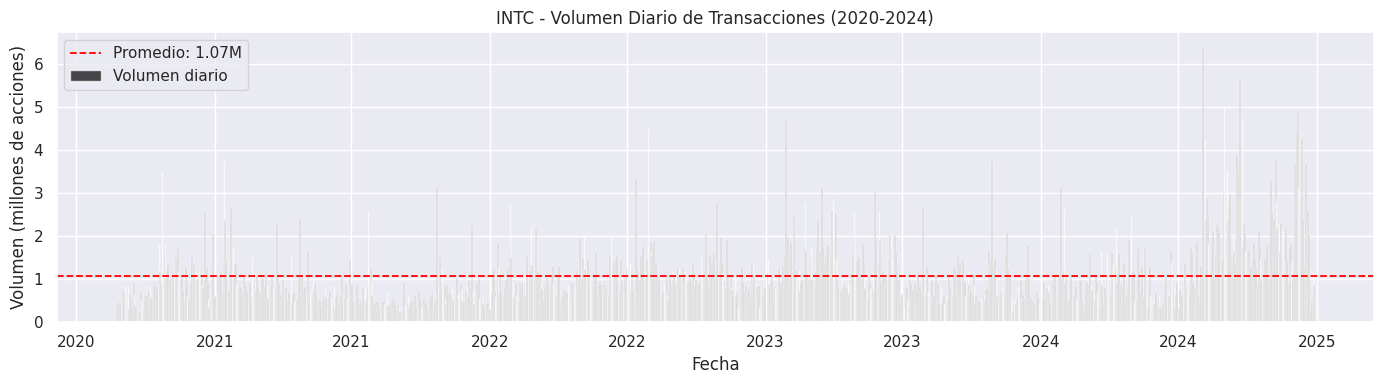

Volumen maximo en un dia : 6.42M acciones
Volumen minimo en un dia : 0.23M acciones


In [100]:
#Gráfica 2 — Volumen de transacciones
# Volumen diario de INTC
# Los picos de volumen suelen coincidir con noticias importantes
# o con los reportes de resultados trimestrales de Intel

fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(df.index, df["volume"] / 1_000_000,
       color="#000000", alpha=0.7, width=1, label="Volumen diario")
ax.axhline(df["volume"].mean() / 1_000_000, color="red", linestyle="--",
           linewidth=1.3, label=f"Promedio: {df['volume'].mean()/1e6:.2f}M")

ax.set_title("INTC - Volumen Diario de Transacciones (2020-2024)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Volumen (millones de acciones)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("../plots/02_volumen.png", dpi=150)
plt.show()

print(f"Volumen maximo en un dia : {df['volume'].max()/1e6:.2f}M acciones")
print(f"Volumen minimo en un dia : {df['volume'].min()/1e6:.2f}M acciones")

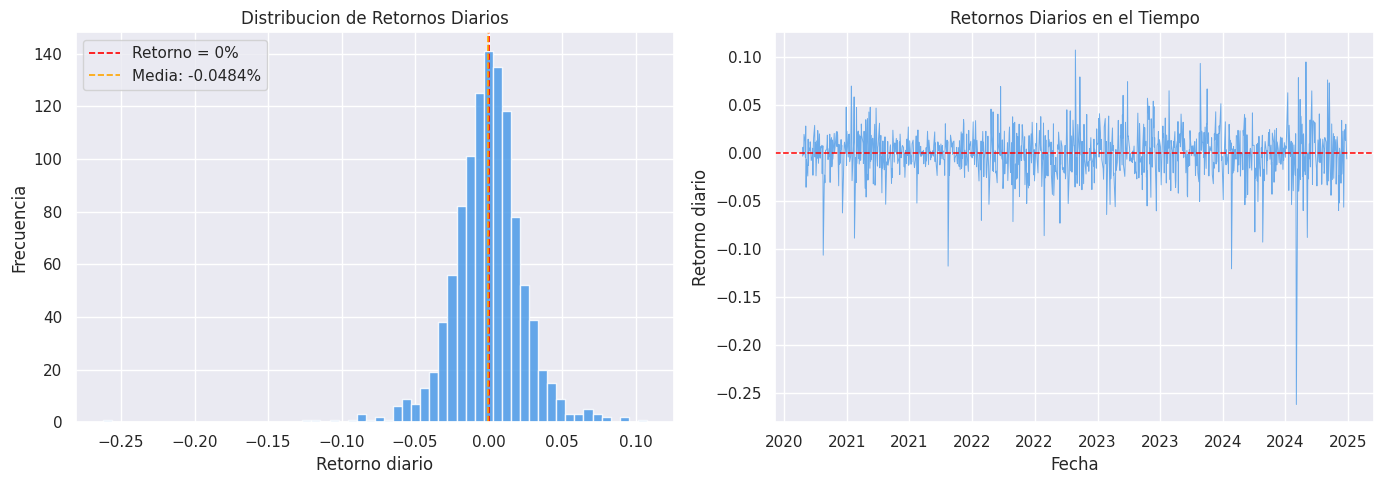

Skewness : -1.2069
Kurtosis : 12.5592
Caida mas grande en un dia  : -26.24%
Subida mas grande en un dia : 10.78%


In [101]:
#Gráfica 3 — Distribución de retornos diarios
# Analizamos la distribucion de los retornos diarios de INTC
# Si la kurtosis es alta hay mas probabilidad de movimientos bruscos
# La persona 1 calculo daily_return como el pct_change del precio de cierre

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de la distribucion
axes[0].hist(df["daily_return"].dropna(), bins=60,
             color="#4C9BE8", edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="red", linestyle="--",
                linewidth=1.2, label="Retorno = 0%")
axes[0].axvline(df["daily_return"].mean(), color="orange", linestyle="--",
                linewidth=1.2, label=f"Media: {df['daily_return'].mean()*100:.4f}%")
axes[0].set_title("Distribucion de Retornos Diarios")
axes[0].set_xlabel("Retorno diario")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Como se ven los retornos a lo largo del tiempo
axes[1].plot(df.index, df["daily_return"],
             color="#4C9BE8", linewidth=0.7, alpha=0.8)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.1)
axes[1].set_title("Retornos Diarios en el Tiempo")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Retorno diario")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("../plots/03_retornos.png", dpi=150)
plt.show()

print(f"Skewness : {df['daily_return'].skew():.4f}")
print(f"Kurtosis : {df['daily_return'].kurt():.4f}")
print(f"Caida mas grande en un dia  : {df['daily_return'].min()*100:.2f}%")
print(f"Subida mas grande en un dia : {df['daily_return'].max()*100:.2f}%")

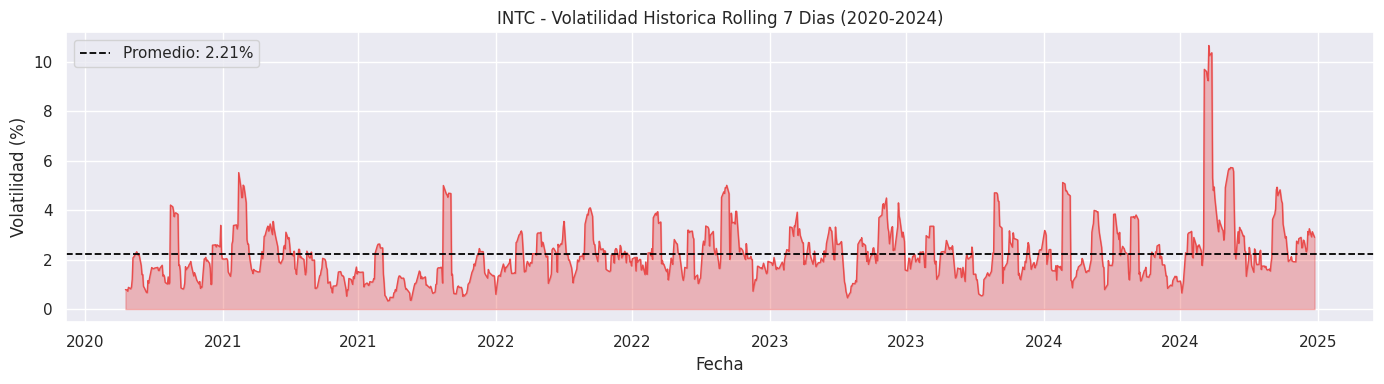

Volatilidad maxima registrada : 10.65%
Volatilidad minima registrada : 0.33%


In [102]:
#Gráfica 4 — Volatilidad histórica rolling 7 días
# Volatilidad de INTC en ventana de 7 dias
# Calculada por nuestro primer companero como desviacion estandar del retorno diario
# Nos permite ver en que momentos el activo tuvo mayor riesgo

fig, ax = plt.subplots(figsize=(14, 4))

ax.fill_between(df.index, df["volatility_7"] * 100,
                alpha=0.35, color="#E84C4C")
ax.plot(df.index, df["volatility_7"] * 100, color="#E84C4C", linewidth=1)
ax.axhline(df["volatility_7"].mean() * 100, color="black", linestyle="--",
           linewidth=1.3, label=f"Promedio: {df['volatility_7'].mean()*100:.2f}%")

ax.set_title("INTC - Volatilidad Historica Rolling 7 Dias (2020-2024)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Volatilidad (%)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("../plots/04_volatilidad.png", dpi=150)
plt.show()

print(f"Volatilidad maxima registrada : {df['volatility_7'].max()*100:.2f}%")
print(f"Volatilidad minima registrada : {df['volatility_7'].min()*100:.2f}%")

/tmp/ipykernel_4372/4128121788.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="year", y="close", palette="Blues", ax=ax, width=0.5)


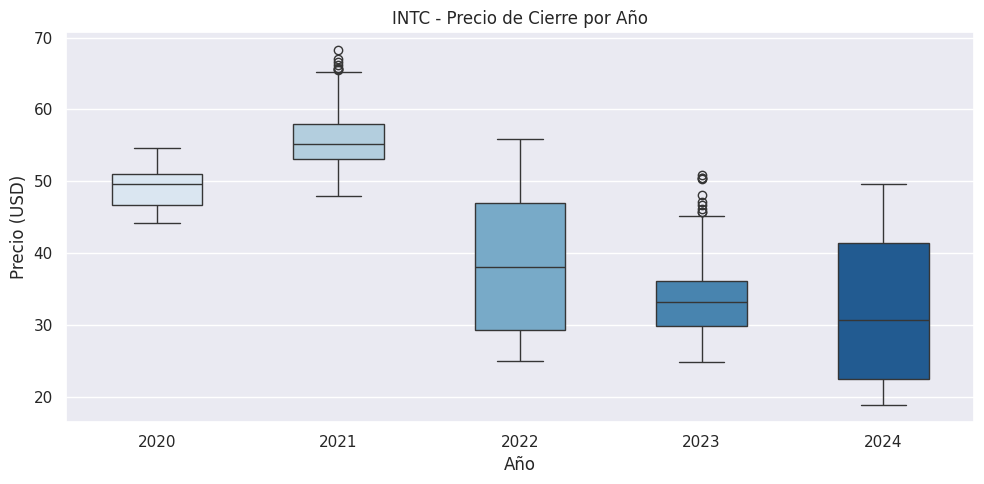

Precio promedio por año:
year
2020    49.20
2021    55.85
2022    38.60
2023    33.83
2024    31.13
Name: close, dtype: float64


In [103]:
#Gráfica 5 — Boxplot del precio por año
# Boxplot para ver como se distribuyo el precio de INTC cada año
# Se puede apreciar claramente la caida de Intel desde 2021 hasta 2024

df["year"] = df.index.year

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="year", y="close", palette="Blues", ax=ax, width=0.5)

ax.set_title("INTC - Precio de Cierre por Año")
ax.set_xlabel("Año")
ax.set_ylabel("Precio (USD)")

plt.tight_layout()
plt.savefig("../plots/05_boxplot_anual.png", dpi=150)
plt.show()

print("Precio promedio por año:")
print(df.groupby("year")["close"].mean().round(2))

df.drop(columns=["year"], inplace=True)

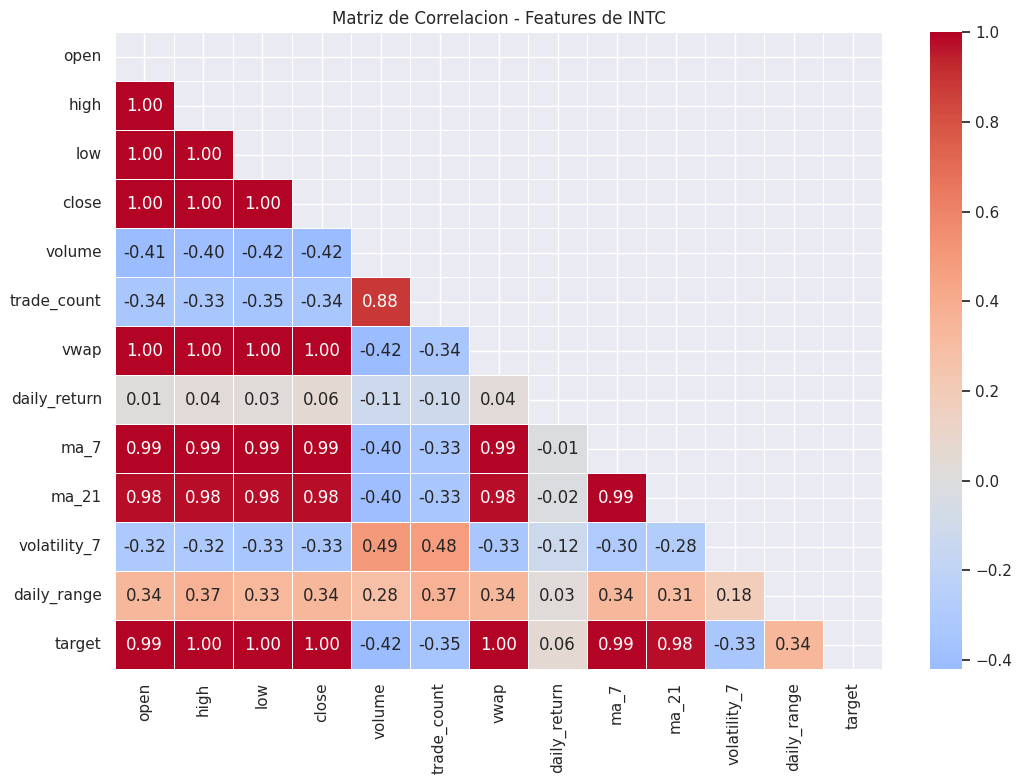

Correlacion de cada variable con el target:
high            1.00
low             1.00
close           1.00
vwap            1.00
open            0.99
ma_7            0.99
ma_21           0.98
daily_range     0.34
daily_return    0.06
volatility_7   -0.33
trade_count    -0.35
volume         -0.42
Name: target, dtype: float64


In [104]:
# Identificación de patrones, tendencias y correlaciones
#Gráfica 6 — Matriz de correlación
# Matriz de correlacion entre todas las variables del dataset
# Lo mas importante es ver que variables tienen mas relacion con el target
# que es el precio de cierre del dia siguiente

corr = df.corr(numeric_only=True).round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5, ax=ax)

ax.set_title("Matriz de Correlacion - Features de INTC")
plt.tight_layout()
plt.savefig("../plots/06_correlacion.png", dpi=150)
plt.show()

# Variables con mayor correlacion con el target
print("Correlacion de cada variable con el target:")
print(corr["target"].drop("target").sort_values(ascending=False).round(4))

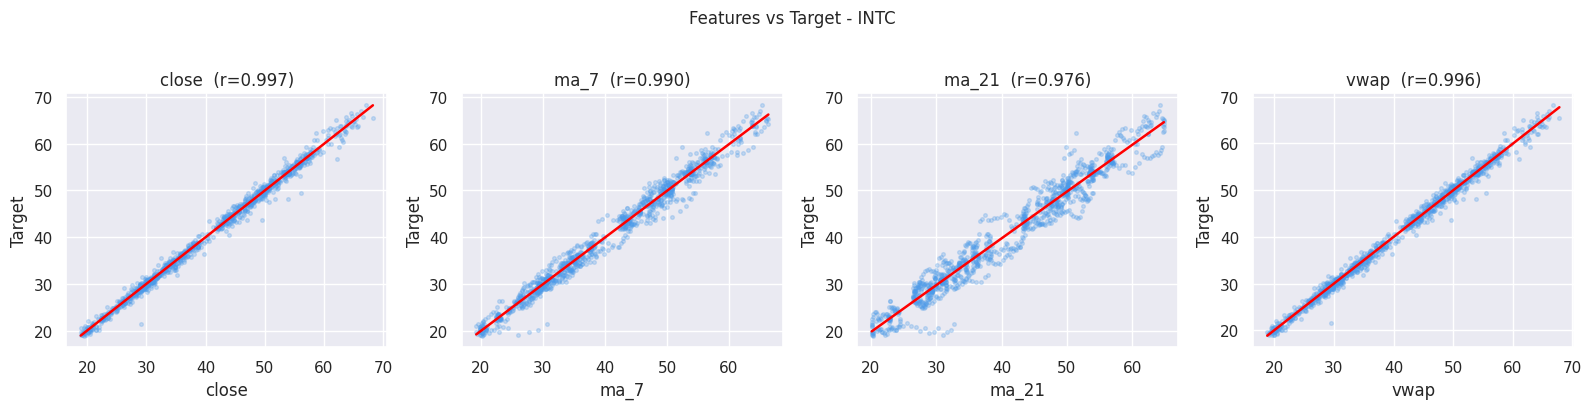

In [105]:
#Gráfica 7 — Relación entre features y el target
# Scatter de las 4 variables con mayor correlacion con el target
# Si la relacion es lineal los modelos de regresion van a funcionar bien
# Esto justifica el uso de regresion lineal que usara la Persona 3

top = ["close", "ma_7", "ma_21", "vwap"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, top):
    ax.scatter(df[col], df["target"], alpha=0.25, s=7, color="#4C9BE8")
    m, b = np.polyfit(df[col].dropna(), df["target"][df[col].notna()], 1)
    x = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x, m * x + b, color="red", linewidth=1.8)
    r = df[col].corr(df["target"])
    ax.set_title(f"{col}  (r={r:.3f})")
    ax.set_xlabel(col)
    ax.set_ylabel("Target")

plt.suptitle("Features vs Target - INTC", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig("../plots/07_scatter_target.png", dpi=150, bbox_inches="tight")
plt.show()

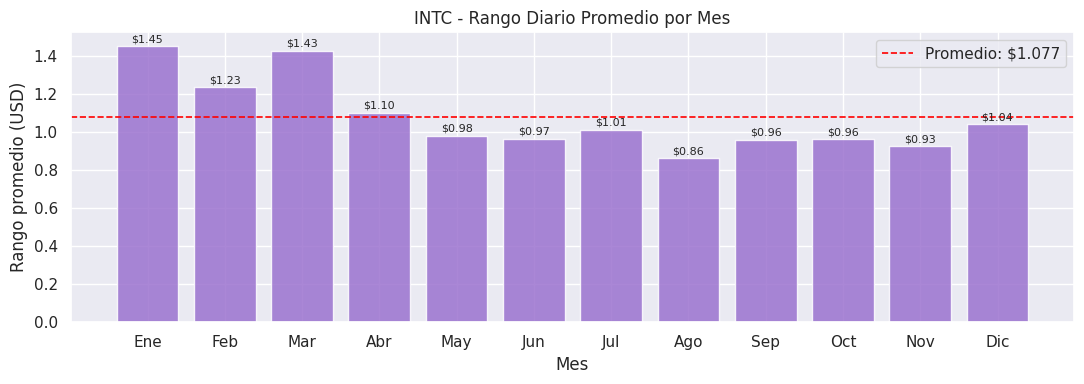

In [106]:
#Gráfica 8 — Estacionalidad del rango diario por mes
# Rango diario promedio agrupado por mes
# Nos dice si hay meses donde INTC se mueve mas que otros
# Los meses de reporte trimestral de Intel (ene, abr, jul, oct)
# suelen tener mayor actividad

df["month"] = df.index.month
meses = ["Ene","Feb","Mar","Abr","May","Jun",
         "Jul","Ago","Sep","Oct","Nov","Dic"]
rango_mes = df.groupby("month")["daily_range"].mean()

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(range(1, 13), rango_mes.values,
              color="#9B72CF", alpha=0.85, edgecolor="white")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses)
ax.axhline(rango_mes.mean(), color="red", linestyle="--",
           linewidth=1.2, label=f"Promedio: ${rango_mes.mean():.3f}")

for bar, val in zip(bars, rango_mes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"${val:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_title("INTC - Rango Diario Promedio por Mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Rango promedio (USD)")
ax.legend()

plt.tight_layout()
plt.savefig("../plots/08_estacionalidad.png", dpi=150)
plt.show()

df.drop(columns=["month"], inplace=True)

In [107]:
#Conclusiones del EDA — Punto 1
# Resumen de los hallazgos del EDA para incluir en el documento del proyecto

print("CONCLUSIONES DEL EDA - INTEL (INTC) 2020-2024")
print("-" * 50)

print(f"""
Dataset:
  {df.shape[0]} registros diarios con {df.shape[1]} features
  Desde {df.index.min().date()} hasta {df.index.max().date()}

Precio:
  Promedio de ${df['close'].mean():.2f} USD con rango de
  ${df['close'].min():.2f} a ${df['close'].max():.2f} USD
  Tendencia alcista hasta 2021 y bajista de 2022 a 2024

Retornos:
  Retorno promedio diario de {df['daily_return'].mean()*100:.4f}%
  El {(df['daily_return'] > 0).mean()*100:.1f}% de los dias fueron positivos
  Kurtosis de {df['daily_return'].kurt():.2f} indica movimientos extremos frecuentes

Volatilidad:
  Promedio del {df['volatility_7'].mean()*100:.4f}% en ventana de 7 dias
  Picos notorios en 2020 (COVID-19) y en 2022-2023

Correlaciones:
  close, vwap, ma_7 y ma_21 tienen correlacion mayor a 0.99 con el target
  Son las features con mayor poder predictivo para los modelos de Persona 3
  daily_return y volatility_7 aportan informacion independiente al modelo

Graficas generadas:
  01_precio_ma.png        - Precio historico con MA7 y MA21
  02_volumen.png          - Volumen diario de transacciones
  03_retornos.png         - Distribucion y serie de retornos
  04_volatilidad.png      - Volatilidad rolling 7 dias
  05_boxplot_anual.png    - Distribucion del precio por año
  06_correlacion.png      - Matriz de correlacion
  07_scatter_target.png   - Relacion features vs target
  08_estacionalidad.png   - Rango diario promedio por mes
""")

CONCLUSIONES DEL EDA - INTEL (INTC) 2020-2024
--------------------------------------------------

Dataset:
  1094 registros diarios con 13 features
  Desde 2020-08-24 hasta 2024-12-27

Precio:
  Promedio de $40.66 USD con rango de
  $18.90 a $68.27 USD
  Tendencia alcista hasta 2021 y bajista de 2022 a 2024

Retornos:
  Retorno promedio diario de -0.0484%
  El 49.5% de los dias fueron positivos
  Kurtosis de 12.56 indica movimientos extremos frecuentes

Volatilidad:
  Promedio del 2.2096% en ventana de 7 dias
  Picos notorios en 2020 (COVID-19) y en 2022-2023

Correlaciones:
  close, vwap, ma_7 y ma_21 tienen correlacion mayor a 0.99 con el target
  Son las features con mayor poder predictivo para los modelos de Persona 3
  daily_return y volatility_7 aportan informacion independiente al modelo

Graficas generadas:
  01_precio_ma.png        - Precio historico con MA7 y MA21
  02_volumen.png          - Volumen diario de transacciones
  03_retornos.png         - Distribucion y serie de r

In [108]:
#HASTA ACA MI PARTE - OSWALDO

### Entrenamiento de modelos

In [109]:
# Carga del dataset procesado

X_scaled = pd.read_csv("/home/data/intc_X_scaled.csv", index_col="timestamp", parse_dates=True)
y = pd.read_csv("/home/data/intc_y.csv", index_col="timestamp", parse_dates=True).squeeze()

print(f'X: {X_scaled.shape[0]} filas x {X_scaled.shape[1]} columnas')
print(f'y: {y.shape[0]} registros')
print(f'\nCaracterísticas: {list(X_scaled.columns)}')
X_scaled.head()

X: 1094 filas x 12 columnas
y: 1094 registros

Características: ['open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'daily_return', 'ma_7', 'ma_21', 'volatility_7', 'daily_range']


,open,high,low,close,volume,trade_count,vwap,daily_return,ma_7,ma_21,volatility_7,daily_range
timestamp,,,,,,,,,,,,
2020-08-24 04:00:00+00:00,0.729584,0.682872,0.736141,0.712140,-1.082346,-1.408261,0.706180,-0.101652,0.691918,0.670635,-1.207429,-0.925688
2020-08-25 04:00:00+00:00,0.725802,0.722480,0.770023,0.738187,-0.868940,-1.243821,0.737970,0.269825,0.698448,0.670225,-1.214698,-0.787131
2020-08-26 04:00:00+00:00,0.730004,0.706220,0.771717,0.744069,-1.181769,-1.647976,0.741743,0.075464,0.705704,0.671352,-1.216621,-1.184328
2020-08-27 04:00:00+00:00,0.765718,0.727483,0.767906,0.736927,-1.120636,-1.610200,0.750060,-0.048950,0.715318,0.676863,-1.260266,-0.630100
2020-08-28 04:00:00+00:00,0.742609,0.800860,0.793317,0.818849,-0.868134,-1.305208,0.812285,0.802680,0.739988,0.686758,-1.129155,0.441406


In [110]:
# División train/test

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, shuffle=False
)

print(f'Entrenamiento: {len(X_train)} registros (80%)')
print(f'Prueba:        {len(X_test)} registros (20%)')

Entrenamiento: 875 registros (80%)
Prueba:        219 registros (20%)


## Entrenamiento de Modelos Lineales
Se entrenaron cuatro modelos: OLS, Ridge, Bayesian Ridge y Lasso.

In [111]:
models = {
    'OLS': LinearRegression(fit_intercept=True),
    'Ridge': Ridge(alpha=1.0, fit_intercept=True, max_iter=1000, random_state=42),
    'Bayesian Ridge': BayesianRidge(max_iter=300, alpha_1=1e-6, alpha_2=1e-6, lambda_1=1e-6, lambda_2=1e-6),
    'Lasso': Lasso(alpha=0.001, fit_intercept=True, max_iter=10000, random_state=42)
}

trained = {}
for nombre, modelo in models.items():
    modelo.fit(X_train, y_train)
    trained[nombre] = modelo
    print(f'{nombre} entrenado')

OLS entrenado
Ridge entrenado
Bayesian Ridge entrenado
Lasso entrenado


In [112]:
# Guardar los modelos
nombres_archivo = {
    'OLS'           : 'ols',
    'Ridge'         : 'ridge',
    'Bayesian Ridge': 'bayesian',
    'Lasso'         : 'lasso'
}
for nombre, modelo in trained.items():
    joblib.dump(modelo, f"/home/models/{nombres_archivo[nombre]}.pkl")
    print(f"{nombre} guardado en /models/{nombres_archivo[nombre]}.pkl")

OLS guardado en /models/ols.pkl
Ridge guardado en /models/ridge.pkl
Bayesian Ridge guardado en /models/bayesian.pkl
Lasso guardado en /models/lasso.pkl


In [113]:
# Metricas de evaluacion

resultados = []
predicciones = {}

for nombre, modelo in trained.items():
    y_pred = modelo.predict(X_test)
    predicciones[nombre] = y_pred
    resultados.append({
        'Modelo': nombre,
        'MAE' : round(mean_absolute_error(y_test, y_pred), 6),
        'MSE' : round(mean_squared_error(y_test, y_pred), 6),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 6),
        'R²'  : round(r2_score(y_test, y_pred), 6)
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print(df_resultados.to_string())

mejor = df_resultados['R²'].idxmax()
print(f'\nMejor modelo: {mejor} (R²: {df_resultados.loc[mejor, "R²"]})')

# Guardar los resultados
df_resultados.reset_index().to_csv("/home/data/resultados_lineales.csv", index=False)
print("Resultados guardados en /data/resultados_lineales.csv")

                     MAE       MSE      RMSE        R²
Modelo                                                
OLS             0.656611  0.982791  0.991358  0.984300
Ridge           0.673169  1.009250  1.004614  0.983878
Bayesian Ridge  0.659501  0.987522  0.993742  0.984225
Lasso           0.651833  0.968715  0.984233  0.984525

Mejor modelo: Lasso (R²: 0.984525)
Resultados guardados en /data/resultados_lineales.csv


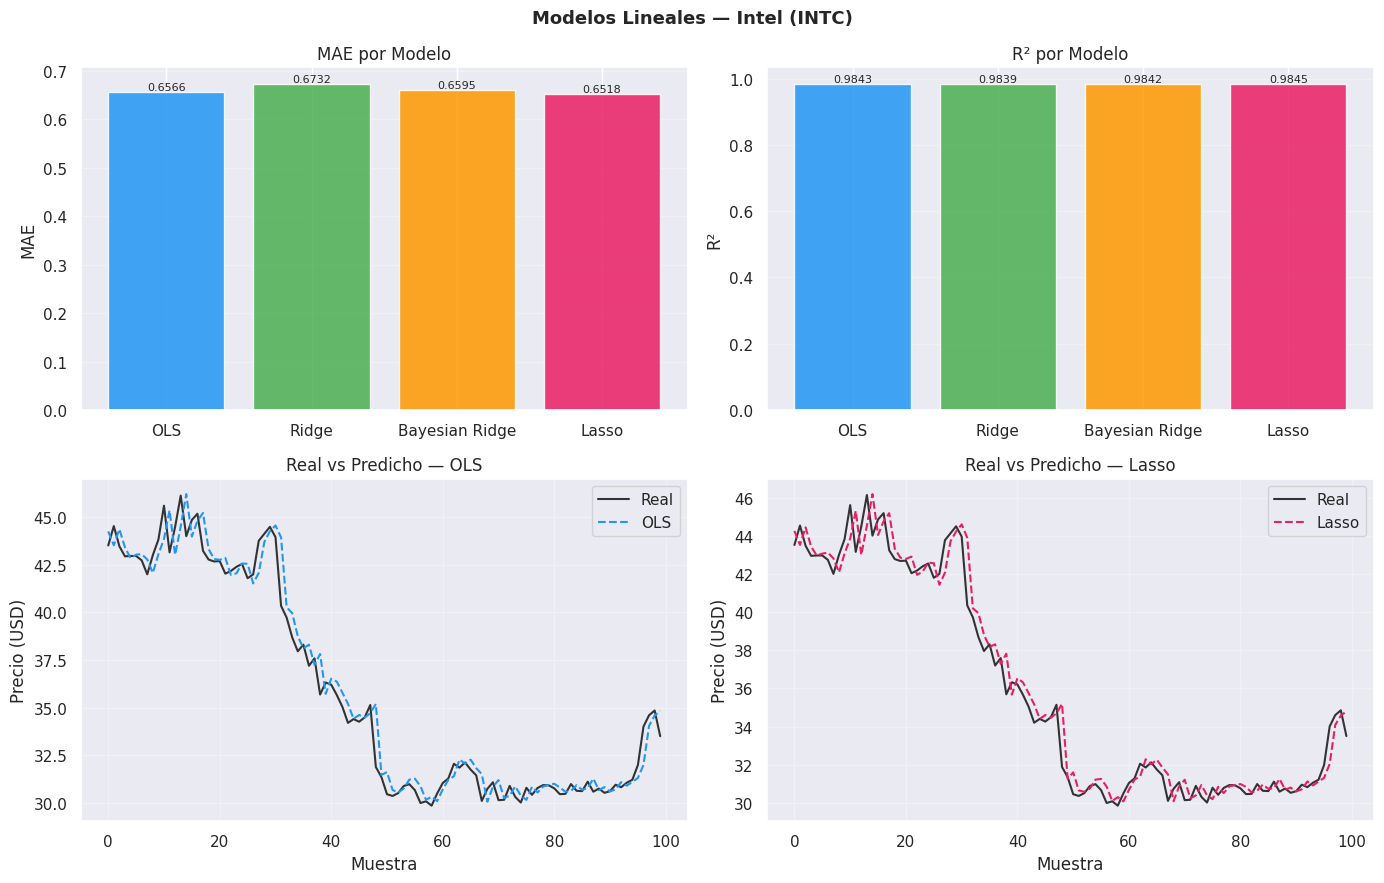

In [114]:
# Visualizacion

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Modelos Lineales — Intel (INTC)', fontsize=13, fontweight='bold')

colores = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
nombres = list(trained.keys())
y_arr   = np.array(y_test)

# MAE
ax   = axes[0, 0]
vals = [df_resultados.loc[n, 'MAE'] for n in nombres]
bars = ax.bar(nombres, vals, color=colores, alpha=0.85)
ax.set_title('MAE por Modelo')
ax.set_ylabel('MAE')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f'{v:.4f}', ha='center', va='bottom', fontsize=8)
ax.grid(axis='y', alpha=0.3)

# R²
ax   = axes[0, 1]
vals = [df_resultados.loc[n, 'R²'] for n in nombres]  # ── AJUSTE 2: R2 → R²
bars = ax.bar(nombres, vals, color=colores, alpha=0.85)
ax.set_title('R² por Modelo')
ax.set_ylabel('R²')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f'{v:.4f}', ha='center', va='bottom', fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Real vs Predicho - OLS
ax = axes[1, 0]
ax.plot(y_arr[:100], label='Real', color='#333', linewidth=1.5)
ax.plot(predicciones['OLS'][:100], label='OLS', color='#2196F3', linewidth=1.5, linestyle='--')
ax.set_title('Real vs Predicho — OLS')
ax.set_xlabel('Muestra')
ax.set_ylabel('Precio (USD)')
ax.legend()
ax.grid(alpha=0.3)

# Real vs Predicho - Mejor modelo
ax = axes[1, 1]
ax.plot(y_arr[:100], label='Real', color='#333', linewidth=1.5)
ax.plot(predicciones[mejor][:100], label=mejor, color='#E91E63', linewidth=1.5, linestyle='--')
ax.set_title(f'Real vs Predicho — {mejor}')
ax.set_xlabel('Muestra')
ax.set_ylabel('Precio (USD)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('resultados_modelos_lineales.png', dpi=150, bbox_inches='tight')
plt.show()

In [115]:
# Los hiperparametros

for nombre, modelo in trained.items():
    print(f'--- {nombre} ---')
    for k, v in modelo.get_params().items():
        print(f'  {k}: {v}')
    print()

--- OLS ---
  copy_X: True
  fit_intercept: True
  n_jobs: None
  positive: False

--- Ridge ---
  alpha: 1.0
  copy_X: True
  fit_intercept: True
  max_iter: 1000
  positive: False
  random_state: 42
  solver: auto
  tol: 0.0001

--- Bayesian Ridge ---
  alpha_1: 1e-06
  alpha_2: 1e-06
  alpha_init: None
  compute_score: False
  copy_X: True
  fit_intercept: True
  lambda_1: 1e-06
  lambda_2: 1e-06
  lambda_init: None
  max_iter: 300
  tol: 0.001
  verbose: False

--- Lasso ---
  alpha: 0.001
  copy_X: True
  fit_intercept: True
  max_iter: 10000
  positive: False
  precompute: False
  random_state: 42
  selection: cyclic
  tol: 0.0001
  warm_start: False



In [116]:
# Carga del dataset

X = pd.read_csv("/home/data/intc_X_scaled.csv", index_col="timestamp", parse_dates=True)
y = pd.read_csv("/home/data/intc_y.csv", index_col="timestamp", parse_dates=True).squeeze()

print(f" Shape de X: {X.shape}")
print(f" Shape de y: {y.shape}")

 Shape de X: (1094, 12)
 Shape de y: (1094,)


In [117]:
# División train/test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False       # Respetamos orden cronológico
)

print(f"División del dataset:")
print(f"   Entrenamiento : {X_train.shape[0]} registros ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Prueba        : {X_test.shape[0]} registros ({X_test.shape[0]/len(X)*100:.0f}%)")

División del dataset:
   Entrenamiento : 875 registros (80%)
   Prueba        : 219 registros (20%)


In [118]:
# Función auxiliar para evaluar modelos

def evaluar_modelo(nombre, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    print(f" {nombre}")
    print(f"   MAE  : {mae:.4f}")
    print(f"   MSE  : {mse:.4f}")
    print(f"   RMSE : {rmse:.4f}")
    print(f"   R²   : {r2:.4f}")
    print("-" * 40)

    return {"Modelo": nombre, "MAE": mae, "MSE": mse, "RMSE": rmse, "R²": r2}

In [119]:
# K-Nearest Neighbors (KNN)

knn = KNeighborsRegressor(
    n_neighbors=5,      # Número de vecinos a considerar
    weights="distance", # Vecinos más cercanos tienen más peso
    metric="euclidean"  # Distancia euclidiana para medir similitud
)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

resultado_knn = evaluar_modelo("KNN Regression", y_test, y_pred_knn)
joblib.dump(knn, "/home/models/knn.pkl")
print(" Modelo KNN guardado")

 KNN Regression
   MAE  : 3.2526
   MSE  : 20.0904
   RMSE : 4.4822
   R²   : 0.6791
----------------------------------------
 Modelo KNN guardado


In [120]:
# Random Forest Regression

rf = RandomForestRegressor(
    n_estimators=100,   # Número de árboles en el bosque
    max_depth=10,       # Profundidad máxima de cada árbol
    min_samples_split=5,# Mínimo de muestras para dividir un nodo
    random_state=42     # Reproducibilidad
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

resultado_rf = evaluar_modelo("Random Forest Regression", y_test, y_pred_rf)
joblib.dump(rf, "/home/models/random_forest.pkl")
print(" Modelo Random Forest guardado")

 Random Forest Regression
   MAE  : 2.0990
   MSE  : 8.5016
   RMSE : 2.9157
   R²   : 0.8642
----------------------------------------
 Modelo Random Forest guardado


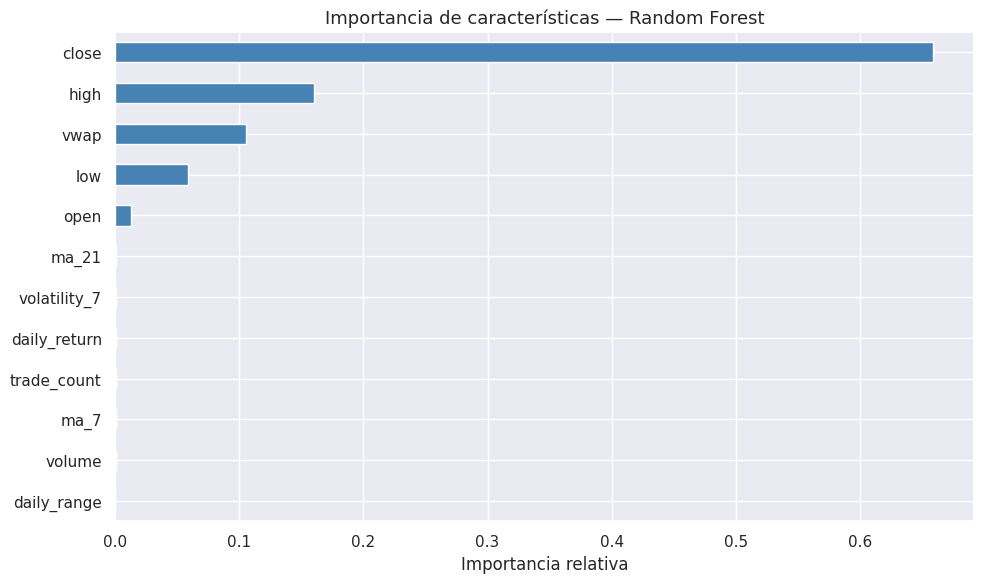


Importancia de características:
close           0.6587
high            0.1599
vwap            0.1056
low             0.0592
open            0.0126
ma_21           0.0007
volatility_7    0.0007
daily_return    0.0007
trade_count     0.0006
ma_7            0.0006
volume          0.0005
daily_range     0.0004
dtype: float64


In [121]:
# Importancia de características (Random Forest)


# Random Forest nos permite ver qué features influyeron más
importancias = pd.Series(rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importancias.plot(kind="barh", color="steelblue")
plt.title("Importancia de características — Random Forest", fontsize=13)
plt.xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

print("\nImportancia de características:")
print(importancias.sort_values(ascending=False).round(4))

In [122]:
# Support Vector Machine (SVM)

svm = SVR(
    kernel="rbf",   # Función de base radial — captura relaciones no lineales
    C=100,          # Penalización por errores — mayor C = menos tolerancia
    epsilon=0.1,    # Margen de tolerancia alrededor de la predicción
    gamma="scale"   # Escala automática según número de features
)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

resultado_svm = evaluar_modelo("SVM Regression", y_test, y_pred_svm)
joblib.dump(svm, "/home/models/svm.pkl")
print("Modelo SVM guardado")

 SVM Regression
   MAE  : 3.2029
   MSE  : 33.4580
   RMSE : 5.7843
   R²   : 0.4655
----------------------------------------
Modelo SVM guardado


In [123]:
# Network MLP Regression

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32), # 3 capas ocultas
    activation="relu",                # Función de activación
    solver="adam",                    # Optimizador
    learning_rate_init=0.001,         # Tasa de aprendizaje inicial
    max_iter=500,                     # Máximo de iteraciones
    early_stopping=True,              # Detiene si no mejora
    n_iter_no_change=20,              # Espera 20 iteraciones antes de detenerse
    validation_fraction=0.1,          # 10% de train para validación interna
    random_state=42
)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

resultado_mlp = evaluar_modelo("MLP Neural Network Regression", y_test, y_pred_mlp)
joblib.dump(mlp, "/home/models/mlp.pkl")
print("Modelo MLP guardado")

 MLP Neural Network Regression
   MAE  : 1.6350
   MSE  : 8.9926
   RMSE : 2.9988
   R²   : 0.8563
----------------------------------------
Modelo MLP guardado


In [124]:
# Hiperparámetros
modelos_avanzados = {
    'KNN'          : knn,
    'Random Forest': rf,
    'SVM'          : svm,
    'MLP'          : mlp
}

for nombre, modelo in modelos_avanzados.items():
    print(f'--- {nombre} ---')
    for k, v in modelo.get_params().items():
        print(f'  {k}: {v}')
    print()

--- KNN ---
  algorithm: auto
  leaf_size: 30
  metric: euclidean
  metric_params: None
  n_jobs: None
  n_neighbors: 5
  p: 2
  weights: distance

--- Random Forest ---
  bootstrap: True
  ccp_alpha: 0.0
  criterion: squared_error
  max_depth: 10
  max_features: 1.0
  max_leaf_nodes: None
  max_samples: None
  min_impurity_decrease: 0.0
  min_samples_leaf: 1
  min_samples_split: 5
  min_weight_fraction_leaf: 0.0
  monotonic_cst: None
  n_estimators: 100
  n_jobs: None
  oob_score: False
  random_state: 42
  verbose: 0
  warm_start: False

--- SVM ---
  C: 100
  cache_size: 200
  coef0: 0.0
  degree: 3
  epsilon: 0.1
  gamma: scale
  kernel: rbf
  max_iter: -1
  shrinking: True
  tol: 0.001
  verbose: False

--- MLP ---
  activation: relu
  alpha: 0.0001
  batch_size: auto
  beta_1: 0.9
  beta_2: 0.999
  early_stopping: True
  epsilon: 1e-08
  hidden_layer_sizes: (128, 64, 32)
  learning_rate: constant
  learning_rate_init: 0.001
  max_fun: 15000
  max_iter: 500
  momentum: 0.9
  n_ite

In [125]:
# Tabla comparativa FINAL de los 8 modelos

# Cargamos resultados de Robert
resultados_lineales = pd.read_csv("/home/data/resultados_lineales.csv")

# Resultados de los modelos avanzados
resultados_avanzados = pd.DataFrame([
    resultado_knn,
    resultado_rf,
    resultado_svm,
    resultado_mlp
])

# Combinamos todos
resultados_finales = pd.concat([resultados_lineales, resultados_avanzados], ignore_index=True)

# Ordenamos por RMSE de menor a mayor
resultados_finales = resultados_finales.sort_values("RMSE").reset_index(drop=True)
resultados_finales.index += 1  # Ranking desde 1

print("Ranking final de los 8 modelos:\n")
print(resultados_finales.to_string())

# Guardar tabla final
resultados_finales.to_csv("/home/data/resultados_finales.csv")
print("\nTabla comparativa final guardada")

Ranking final de los 8 modelos:

                          Modelo       MAE        MSE      RMSE        R²
1                          Lasso  0.651833   0.968715  0.984233  0.984525
2                            OLS  0.656611   0.982791  0.991358  0.984300
3                 Bayesian Ridge  0.659501   0.987522  0.993742  0.984225
4                          Ridge  0.673169   1.009250  1.004614  0.983878
5       Random Forest Regression  2.098951   8.501553  2.915742  0.864191
6  MLP Neural Network Regression  1.634954   8.992587  2.998764  0.856347
7                 KNN Regression  3.252561  20.090424  4.482234  0.679064
8                 SVM Regression  3.202894  33.458016  5.784290  0.465523

Tabla comparativa final guardada


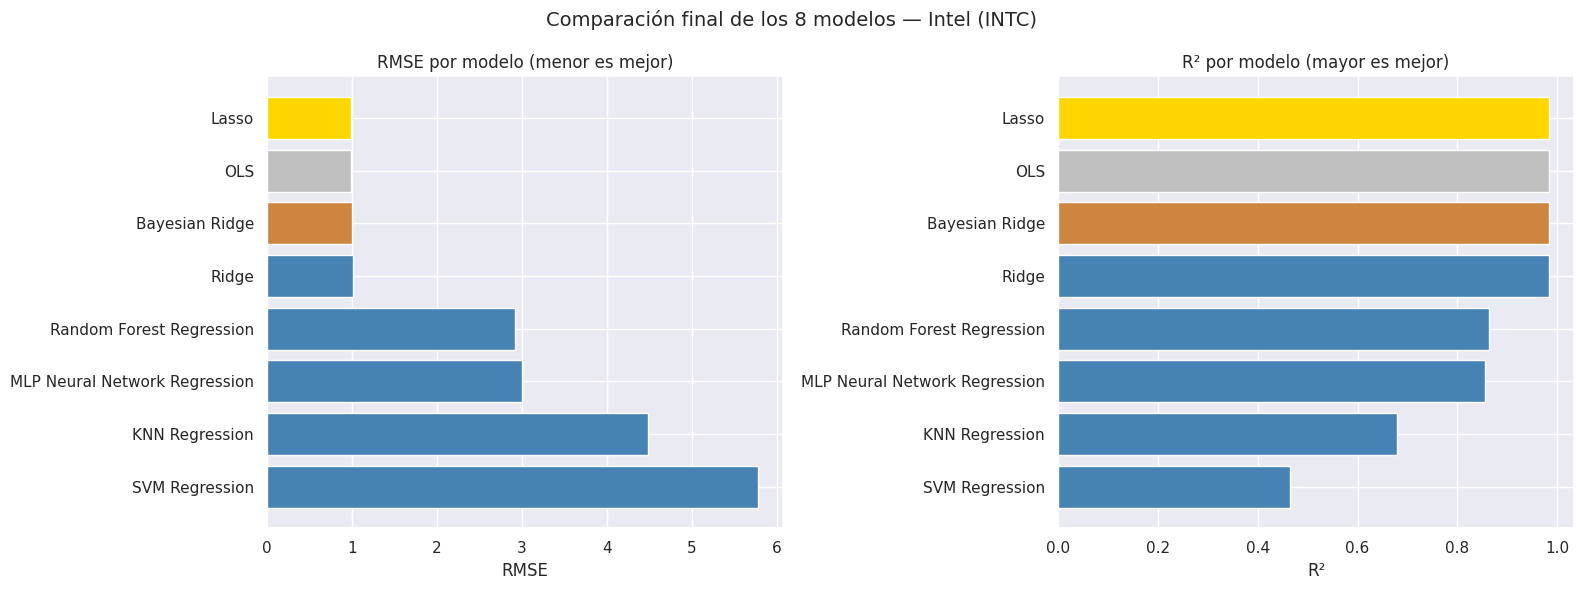

In [126]:
# Gráfica comparativa de métricas

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colores = ["gold" if i == 1 else "silver" if i == 2
           else "peru" if i == 3 else "steelblue"
           for i in range(1, len(resultados_finales) + 1)]

# RMSE por modelo
axes[0].barh(resultados_finales["Modelo"], resultados_finales["RMSE"],
             color=colores)
axes[0].set_title("RMSE por modelo (menor es mejor)", fontsize=12)
axes[0].set_xlabel("RMSE")
axes[0].invert_yaxis()

# R² por modelo
axes[1].barh(resultados_finales["Modelo"], resultados_finales["R²"],
             color=colores)
axes[1].set_title("R² por modelo (mayor es mejor)", fontsize=12)
axes[1].set_xlabel("R²")
axes[1].invert_yaxis()

plt.suptitle("Comparación final de los 8 modelos — Intel (INTC)", fontsize=14)
plt.tight_layout()
plt.show()

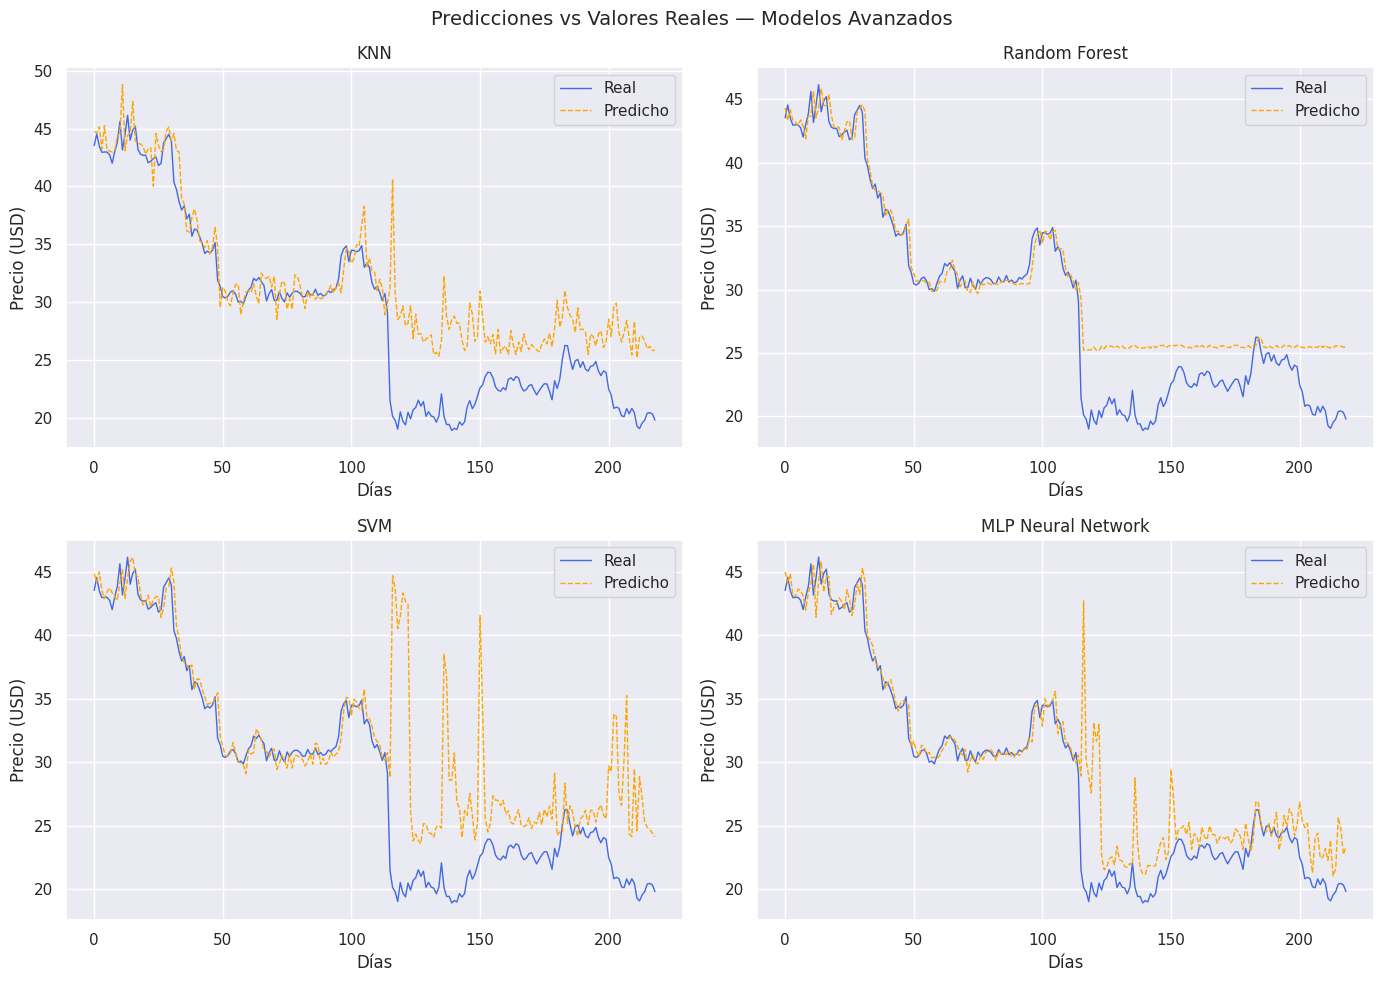

In [127]:
# Gráfica predicciones vs valores reales

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
modelos = [
    ("KNN", y_pred_knn),
    ("Random Forest", y_pred_rf),
    ("SVM", y_pred_svm),
    ("MLP Neural Network", y_pred_mlp)
]

for ax, (nombre, y_pred) in zip(axes.flatten(), modelos):
    ax.plot(y_test.values, label="Real",     color="royalblue", linewidth=1)
    ax.plot(y_pred,        label="Predicho", color="orange",    linewidth=1, linestyle="--")
    ax.set_title(nombre)
    ax.set_xlabel("Días")
    ax.set_ylabel("Precio (USD)")
    ax.legend()

plt.suptitle("Predicciones vs Valores Reales — Modelos Avanzados", fontsize=14)
plt.tight_layout()
plt.show()

# Prediccion


In [128]:
# Imports
from datetime import datetime, timedelta

# Alpaca
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [129]:
# Cargar modelo y scaler

lasso  = joblib.load("/home/models/random_forest.pkl")
scaler = joblib.load("/home/models/scaler.pkl")

print("Modelo Lasso cargado")
print("Scaler cargado")

Modelo Lasso cargado
Scaler cargado


In [130]:
# Obtener datos actualizados hasta hoy


def obtener_datos_actualizados(ticker="INTC"):
    """
    Descarga los últimos 45 días calendario del ticker
    para garantizar al menos 21 días hábiles.
    Guarda el CSV y lo retorna como DataFrame.
    """

    hoy = datetime.now()
    hace_45 = hoy - timedelta(days=45)

    request = StockBarsRequest(
        symbol_or_symbols=ticker,
        timeframe=TimeFrame.Day,
        start=hace_45,
        end=hoy,
        feed="iex"
    )

    bars = client.get_stock_bars(request)
    df   = bars.df.reset_index()
    df   = df.drop(columns=["symbol"])

    # Guardamos CSV
    df.to_csv("/home/data/nuevo_dataset.csv", index=False)

    print(f"Datos obtenidos hasta : {hoy.strftime('%Y-%m-%d')}")
    print(f"Registros obtenidos  : {df.shape[0]} días hábiles")
    print(f"\nÚltimos 3 registros:")
    print(df.tail(3).to_string(index=False))

    return df

# Ejecutamos
df_actual = obtener_datos_actualizados()

Datos obtenidos hasta : 2026-03-27
Registros obtenidos  : 32 días hábiles

Últimos 3 registros:
                timestamp   open   high   low  close    volume  trade_count      vwap
2026-03-24 04:00:00+00:00 43.420 44.310 43.22  44.08 2630955.0      13815.0 43.791154
2026-03-25 04:00:00+00:00 45.940 47.835 45.45  47.20 3037507.0      18236.0 47.108091
2026-03-26 04:00:00+00:00 46.305 46.600 43.92  44.10 2427540.0      18083.0 44.771829


In [131]:
# Pipeline de preprocesamiento

def preprocesar_csv(filepath):
    """
    Recibe un CSV con datos históricos crudos de INTC
    y aplica el mismo pipeline de preprocesamiento del entrenamiento.
    """

    df = pd.read_csv(filepath, parse_dates=["timestamp"])
    df = df.set_index("timestamp")
    print(f"CSV cargado: {df.shape[0]} registros, {df.shape[1]} columnas")

    # Eliminamos columna symbol si existe
    if "symbol" in df.columns:
        df = df.drop(columns=["symbol"])

    # Verificamos columnas mínimas necesarias
    columnas_requeridas = ["open", "high", "low", "close", "volume", "trade_count", "vwap"]
    faltantes = [col for col in columnas_requeridas if col not in df.columns]
    if faltantes:
        raise ValueError(f"Columnas requeridas no encontradas: {faltantes}")

    # Verificamos registros suficientes para ma_21
    if len(df) < 22:
        raise ValueError(f"El CSV necesita al menos 22 registros, tiene {len(df)}")

    # Ingeniería de características — idéntica al entrenamiento
    df["daily_return"] = df["close"].pct_change()
    df["ma_7"]         = df["close"].rolling(window=7).mean()
    df["ma_21"]        = df["close"].rolling(window=21).mean()
    df["volatility_7"] = df["daily_return"].rolling(window=7).std()
    df["daily_range"]  = df["high"] - df["low"]

    # Eliminamos target si existe
    if "target" in df.columns:
        df = df.drop(columns=["target"])

    # Eliminamos filas con NaN generadas por rolling
    df = df.dropna()

    print(f"Preprocesamiento completado: {df.shape[0]} registros válidos")
    return df

In [132]:
# Función de predicción

def predecir_precios(filepath):
    """
    Recibe un CSV con datos históricos crudos,
    aplica el pipeline completo y genera predicciones.
    """

    df_nuevo     = preprocesar_csv(filepath)
    X_nuevo      = scaler.transform(df_nuevo)
    predicciones = lasso.predict(X_nuevo)

    df_resultados = pd.DataFrame({
        "fecha"           : df_nuevo.index,
        "precio_real"     : df_nuevo["close"].values,
        "precio_predicho" : predicciones.round(4),
        "diferencia"      : (predicciones - df_nuevo["close"].values).round(4),
        "error_%"         : (abs(predicciones - df_nuevo["close"].values)
                            / df_nuevo["close"].values * 100).round(2)
    })

    return df_resultados

In [133]:
# Función para graficar predicciones

def graficar_predicciones(df_resultados):

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Gráfica 1 — Precio real vs predicho
    axes[0].plot(df_resultados["fecha"], df_resultados["precio_real"],
                 label="Precio real",     color="royalblue", linewidth=1.5)
    axes[0].plot(df_resultados["fecha"], df_resultados["precio_predicho"],
                 label="Precio predicho", color="orange",    linewidth=1.5, linestyle="--")
    axes[0].set_title("Precio Real vs Precio Predicho — Intel (INTC)", fontsize=13)
    axes[0].set_xlabel("Fecha")
    axes[0].set_ylabel("Precio (USD)")
    axes[0].legend()

    # Gráfica 2 — Error porcentual
    axes[1].bar(df_resultados["fecha"], df_resultados["error_%"],
                color="crimson", alpha=0.6, width=1)
    axes[1].axhline(df_resultados["error_%"].mean(), color="black",
                    linestyle="--", linewidth=1, label=f'Error promedio: {df_resultados["error_%"].mean():.2f}%')
    axes[1].set_title("Error porcentual por día (%)", fontsize=13)
    axes[1].set_xlabel("Fecha")
    axes[1].set_ylabel("Error (%)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Estadísticas del error
    print(f"\nEstadísticas de predicción:")
    print(f"   Registros analizados : {len(df_resultados)}")
    print(f"   Error promedio       : ${abs(df_resultados['diferencia']).mean():.4f}")
    print(f"   Error máximo         : ${abs(df_resultados['diferencia']).max():.4f}")
    print(f"   Error % promedio     : {df_resultados['error_%'].mean():.2f}%")
    print(f"   Error % máximo       : {df_resultados['error_%'].max():.2f}%")

CSV cargado: 32 registros, 7 columnas
Preprocesamiento completado: 12 registros válidos
         🔮 PREDICCIÓN INTEL (INTC)
   Fecha del último dato  : 2026-03-26
   Precio ayer            : $47.20
   Precio hoy             : $44.10  ( Bajó $3.10 hoy)
----------------------------------------------------
   Precio estimado mañana : $44.46
  🟢 Dirección estimada     :  SUBE
   Variación estimada     : $+0.36 (+0.81%)
----------------------------------------------------
   Rango probable:
     Mínimo   → $44.00
     Estimado → $44.46
     Máximo   → $44.91
----------------------------------------------------
   Nivel de confianza     : Media  🟡
     (error promedio histórico: 1.03%)

 Últimas 5 predicciones para contexto:
                    fecha  precio_real  precio_predicho  diferencia  error_%
2026-03-20 04:00:00+00:00        43.94          44.8990      0.9590     2.18
2026-03-23 04:00:00+00:00        44.00          44.2232      0.2232     0.51
2026-03-24 04:00:00+00:00        44.08   

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


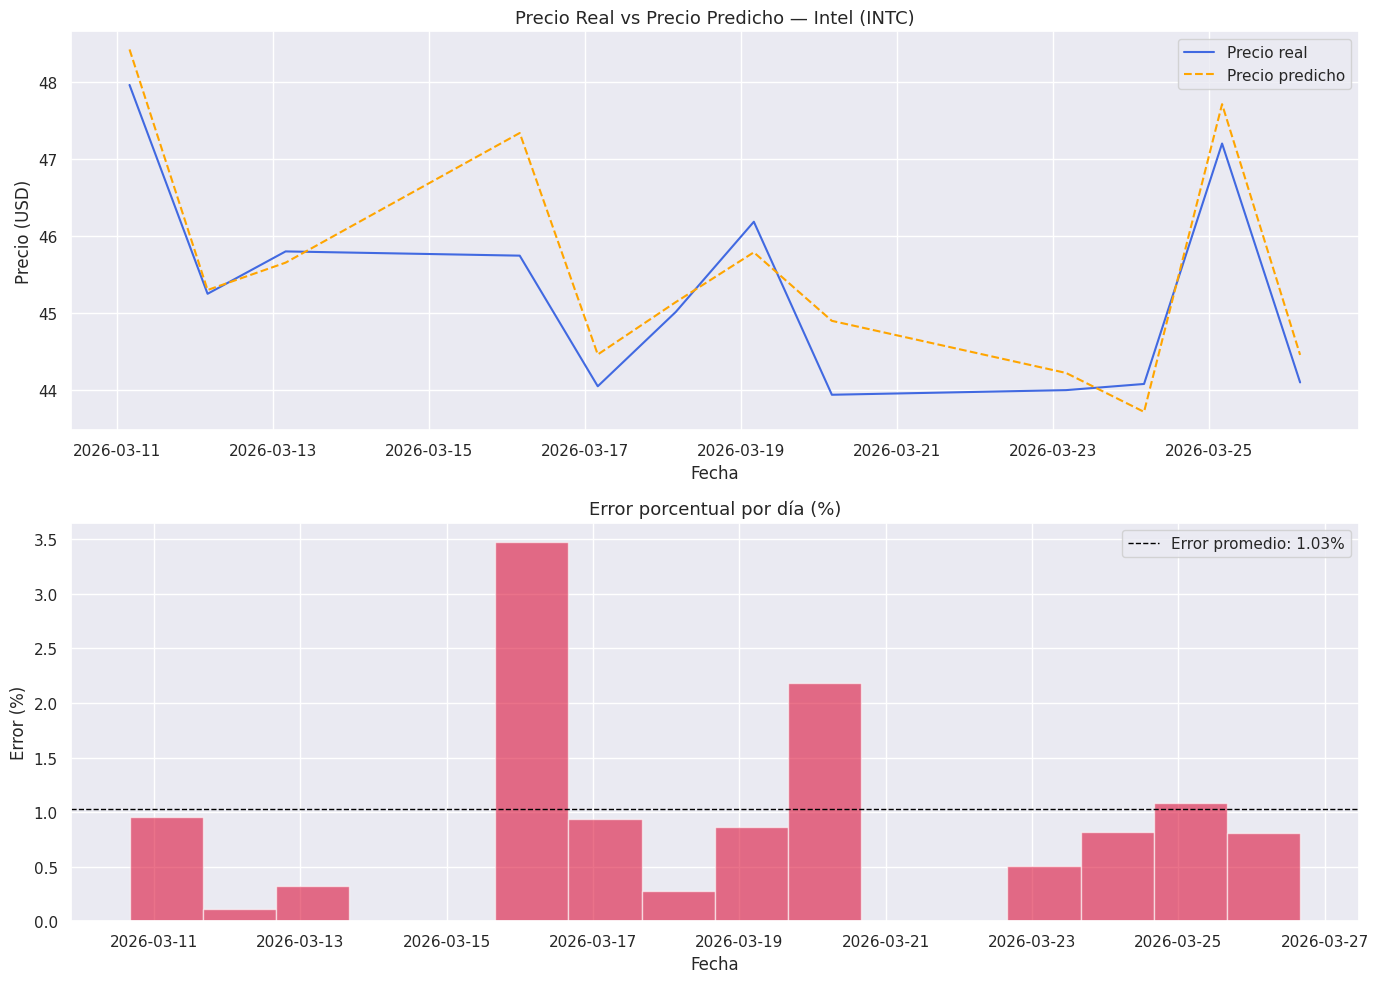


Estadísticas de predicción:
   Registros analizados : 12
   Error promedio       : $0.4663
   Error máximo         : $1.5916
   Error % promedio     : 1.03%
   Error % máximo       : 3.48%

 Predicciones guardadas en /data/predicciones_resultado.csv


In [134]:
# Ejecutar predicción y mostrar señal

def ejecutar_prediccion(csv_path):
    """
    Pipeline completo:
    1. Preprocesa el CSV
    2. Genera predicciones
    3. Muestra señal del día siguiente
    4. Muestra gráficas
    5. Guarda resultados
    """

    if not os.path.exists(csv_path):
        print("  No se encontró el archivo CSV.")
        print(f"    Coloca tu archivo en: {csv_path}")
        print("    El archivo debe tener las columnas:")
        print("    timestamp, open, high, low, close, volume, trade_count, vwap")
        return None

    # Pipeline completo
    df_resultados = predecir_precios(csv_path)

    # ── Análisis del último día ───────────────────────────────
    ultimo          = df_resultados.iloc[-1]
    penultimo       = df_resultados.iloc[-2]
    precio_hoy      = ultimo["precio_real"]
    precio_ayer     = penultimo["precio_real"]
    precio_manana   = ultimo["precio_predicho"]
    diferencia      = precio_manana - precio_hoy
    porcentaje      = (diferencia / precio_hoy) * 100
    tendencia_hoy   = precio_hoy - precio_ayer

    # Señal de dirección
    if diferencia > 0:
        señal     = " SUBE"
        color_msg = "🟢"
    elif diferencia < 0:
        señal     = " BAJA"
        color_msg = "🔴"
    else:
        señal     = "  SIN CAMBIO"
        color_msg = "🟡"

    # Tendencia reciente
    if tendencia_hoy > 0:
        tendencia_msg = f" Subió ${tendencia_hoy:.2f} hoy"
    elif tendencia_hoy < 0:
        tendencia_msg = f" Bajó ${abs(tendencia_hoy):.2f} hoy"
    else:
        tendencia_msg = "  Sin cambio hoy"

    # Nivel de confianza basado en error promedio histórico
    error_promedio = df_resultados["error_%"].mean()
    if error_promedio < 1:
        confianza = "Alta   🟢"
    elif error_promedio < 3:
        confianza = "Media  🟡"
    else:
        confianza = "Baja   🔴"

    # Rango probable
    margen        = precio_manana * (error_promedio / 100)
    precio_minimo = precio_manana - margen
    precio_maximo = precio_manana + margen

    # ── Resumen de predicción ─────────────────────────────────
    print("=" * 52)
    print("         🔮 PREDICCIÓN INTEL (INTC)")
    print("=" * 52)
    print(f"   Fecha del último dato  : {ultimo['fecha'].strftime('%Y-%m-%d')}")
    print(f"   Precio ayer            : ${precio_ayer:.2f}")
    print(f"   Precio hoy             : ${precio_hoy:.2f}  ({tendencia_msg})")
    print("-" * 52)
    print(f"   Precio estimado mañana : ${precio_manana:.2f}")
    print(f"  {color_msg} Dirección estimada     : {señal}")
    print(f"   Variación estimada     : ${diferencia:+.2f} ({porcentaje:+.2f}%)")
    print("-" * 52)
    print(f"   Rango probable:")
    print(f"     Mínimo   → ${precio_minimo:.2f}")
    print(f"     Estimado → ${precio_manana:.2f}")
    print(f"     Máximo   → ${precio_maximo:.2f}")
    print("-" * 52)
    print(f"   Nivel de confianza     : {confianza}")
    print(f"     (error promedio histórico: {error_promedio:.2f}%)")
    print("=" * 52)

    # Últimas 5 predicciones para contexto
    print(f"\n Últimas 5 predicciones para contexto:")
    print(df_resultados[["fecha", "precio_real", "precio_predicho",
                          "diferencia", "error_%"]].tail(5).to_string(index=False))

    # Gráficas
    graficar_predicciones(df_resultados)

    # Guardamos resultados
    df_resultados.to_csv("/home/data/predicciones_resultado.csv", index=False)
    print("\n Predicciones guardadas en /data/predicciones_resultado.csv")

    return df_resultados

# Ejecutamos
df_resultados = ejecutar_prediccion("/home/data/nuevo_dataset.csv")